1. Binary Classification to MNIST
Recognize single digit from dataset and leave rest for next chapter. Starting simple!

Digits consist of 28 by 28 grayscale pixels, each represented by one byte. In MNIST’s grayscale, 0 stands for “perfect background white,” and 255 stands for “perfect foreground black.”


Prepare the input matrices

Binary classifier expects its input formatted as two matrices: features X, lable Y

X is supposed to have one line per example and one column per input variable, plus a bias column full of 1s.

To fit MNIST’s images to this format, we can reshape each image to a single line of pixels so that each pixel becomes an input variable. MNIST images are 28 by 28 pixels, so squashing them results in lines of 784 elements. And throw in the bias column, and that makes 785. So, X should look like a matrix of 60,000 lines (the number of examples) and 785 columns (one per pixel, plus the bias).

Now let’s look at Y, the matrix of labels. At first glance, it looks simpler than the matrix of images. It still has one line per example, but only one column, that contains the label. However, we have an additional difficulty here. So far, we have only built binary classifiers, which expect a label that’s either 0 or 1. By contrast, MNIST labels range from 0 to 9. How can we fit ten different values into either 0 or 1?

For now, we can work around that problem by narrowing our scope. Let’s start by recognizing one specific digit, the digit 5. This is a binary classification problem because a digit can belong to two classes: “not a 5” and “5.”

This means that we should convert all MNIST labels to 0s, except for 5s, which we should convert to 1s.

Dataset used:

https://www.kaggle.com/datasets/hojjatk/mnist-dataset?resource=download-directory

In [51]:
# An MNIST loader.
import numpy as np
import gzip
import struct

In [52]:
#Load Images

def load_images(filename):
    #open file of images
    with open(filename,'rb') as f:
        #read header and unpack into variables
        _ignored,n_images,columns,rows = struct.unpack('>IIII',f.read(16))
        #read all pixels into numpy array of bytes
        all_pixels = np.frombuffer(f.read(),dtype=np.uint8)
        #reshape pixels into a matrix where each line is an image
        return all_pixels.reshape(n_images,columns*rows)
    
def prepend_bias(X):
    #Insert column of 1s at poisition 0 of X.
    # axis=1 means insert a column, not a row.
    return np.insert(X,0,1, axis=1)

In [53]:
#Load Labels

def load_labels(filename):
    with open(filename,'rb') as f:
        #skip the header bytes:
        f.read(8)
        #Read all the labels into list:
        all_labels = f.read()
        #Reshape the list of labels into one-column matrix:
        return np.frombuffer(all_labels,dtype=np.uint8).reshape(-1,1)

def encode_five(Y):
    #convert lable 5 to 1 and rest to 0
    return (Y==5).astype(int)


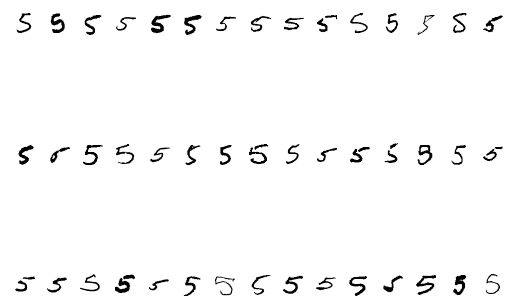

In [54]:
import numpy as np
import matplotlib.pyplot as plt

DIGIT = 5

X = load_images("Datasets/archive/train-images-idx3-ubyte/train-images-idx3-ubyte")
Y = load_labels("Datasets/archive/train-labels-idx1-ubyte/train-labels-idx1-ubyte").flatten()
digits = X[Y==DIGIT]
np.random.shuffle(digits)

rows,columns = 3,15
fig = plt.figure()
for i in range(rows*columns):
    ax = fig.add_subplot(rows,columns,i+1)
    ax.axis('off')
    ax.imshow(digits[i].reshape((28,28)),cmap="Greys")
plt.show()

In [55]:
#The Real thing -> Classifying 5 from trained classifier model

# Applying Logistic Regression
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Basically doing prediction but named forward as its 
# performing Forward-Propagation
def forward(X, w):
    weighted_sum = np.matmul(X, w)
    return sigmoid(weighted_sum)

# Calling the predict() function
def classify(X, w):
    return np.round(forward(X, w))


# Computing Loss over using logistic regression
def loss(X, Y, w):
    y_hat = forward(X, w)
    first_term = Y * np.log(y_hat)
    second_term = (1 - Y) * np.log(1 - y_hat)
    return -np.average(first_term + second_term)


# calculating gradient
def gradient(X, Y, w):
    return np.matmul(X.T, (forward(X, w) - Y)) / X.shape[0]

# calling the training function for desired no. of iterations
def train(X, Y, iterations, lr):
    w = np.zeros((X.shape[1], 1))
    for i in range(iterations):
        print('Iteration %4d => Loss: %.20f' % (i, loss(X, Y, w)))
        w -= gradient(X, Y, w) * lr
    return w

# Doing inference to test our model
def test(X, Y, w):
    total_examples = X.shape[0]
    correct_results = np.sum(classify(X, w) == Y)
    success_percent = correct_results * 100 / total_examples
    print("\nSuccess: %d/%d (%.2f%%)" %
          (correct_results, total_examples, success_percent))

In [56]:
# 60000 images, each 785 elements (1 bias + 28 * 28 pixels)
X_train = prepend_bias(load_images("Datasets/archive/train-images-idx3-ubyte/train-images-idx3-ubyte"))

# 10000 images, each 785 elements, with the same structure as X_train
X_test = prepend_bias(load_images("Datasets/archive/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte"))

# 60K labels, each with value 1 if the digit is a five, and 0 otherwise
Y_train = encode_five(load_labels("Datasets/archive/train-labels-idx1-ubyte/train-labels-idx1-ubyte"))

# 10000 labels, with the same encoding as Y_train
Y_test = encode_five(load_labels("Datasets/archive/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte"))


In [57]:
w = train(X_train, Y_train, iterations=100, lr=1e-5)
test(X_test, Y_test, w)

Iteration    0 => Loss: 0.69314718055994528623
Iteration    1 => Loss: 0.80042530259490185518
Iteration    2 => Loss: 0.60370180008019180828
Iteration    3 => Loss: 0.41561114405207100209
Iteration    4 => Loss: 0.26488539455552501112
Iteration    5 => Loss: 0.21974966586468008822
Iteration    6 => Loss: 0.21169719667449560241
Iteration    7 => Loss: 0.20475082478710041056
Iteration    8 => Loss: 0.19886878484015674262
Iteration    9 => Loss: 0.19372162858641284178
Iteration   10 => Loss: 0.18918194048765815674
Iteration   11 => Loss: 0.18512959704505968506
Iteration   12 => Loss: 0.18148156040801419198
Iteration   13 => Loss: 0.17817479685293546865
Iteration   14 => Loss: 0.17515915471115794944
Iteration   15 => Loss: 0.17239535061657859649
Iteration   16 => Loss: 0.16985095072606279376
Iteration   17 => Loss: 0.16749932830345123924
Iteration   18 => Loss: 0.16531807243088861292
Iteration   19 => Loss: 0.16328826613520674993
Iteration   20 => Loss: 0.16139375633494251749
Iteration   2

Now to check for all digits from 0 to 9. We can call the trainer -> get the trained weight -> predict. We need to do this by number of callses times and trainning weights 10 times. 
Lot's of compute power waste. Too much repetative work, right?      
This leads to next evalution for multi-class classifier.

Multi-Class Classifier for MNIST

One Hot Encoding => Matrix with 10 columns (one per each class) and rows = no. of examples

This way of encoding labels is called one-hot encoding, because only one value per row is 
1. The rest are zeros.

We don’t run our code ten times, once per class. Instead, we run it once, with one column per class. It’s as if each column in the matrix contained the binary encoding for one of the WSSs [Weighted Sum plus Sigmoid]. This matrix multiplication-based approach works just as well as running a classifier ten times, but it’s much faster.

One-hot encoding is redundant: instead of one number per example, we have as many numbers as we have classes. But that redundancy is usually worth it.

In [58]:
#let's replace encode_five() with one hot encoding for all the classes

def one_hot_encode(Y):
    n_labels = Y.shape[0]
    n_classes = 10
    encoded_Y = np.zeros((n_labels,n_classes))
    for i in range(n_labels):
        label = Y[i]
        encoded_Y[i][label]=1
    return encoded_Y

The one_hot_encode() initializes a matrix of zeros with one row per label and one column per class (Y.shape[0] means the number of rows in Y). Then it walks through the matrix, flipping values to 1. We can use this function to initialize a one-hot encoded version of Y_train:

In [59]:
#60k labels, each with single digit from 0 to 9
Y_train_unencoded = load_labels("Datasets/archive/train-labels-idx1-ubyte/train-labels-idx1-ubyte")
Y_train_encoded = one_hot_encode(Y_train_unencoded)

#10k labels, each from 0 to 9
Y_test = load_labels("Datasets/archive/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte")


'''
Why we encoded training labels but not encoded test labels?

because now new classify() function will not only return probability range from 0 to 1 
but we will get the argmax out of all the WSS and return back human redable label 
like from 0 to 9. 

Hence, no need to encode test labels.
'''



'\nWhy we encoded training labels but not encoded test labels?\n\nbecause now new classify() function will not only return probability range from 0 to 1 \nbut we will get the argmax out of all the WSS and return back human redable label \nlike from 0 to 9. \n\nHence, no need to encode test labels.\n'

In [60]:
#calling the predict function
def classify(X,w):
    y_hat = forward(X,w)
    labels = np.argmax(y_hat,axis=1)
    return labels.reshape(-1,1)

The first line of classify() calculates a matrix of predictions ^y, 
with one row per label, and one column per class. Each row in ^y contains ten numbers between 0 and 1.
The second line uses NumPy’s argmax() function to get the index of the maximum value in each row of ^y, or the value closer to 1. By default, argmax() finds the maximum value in the entire matrix, so this code uses the argument axis=1 to apply it to each row separately. The result is an array of indices, which are also the decoded MNIST labels. We might practice with functions like argmax() in an interactive Python interpreter before using them. On the other hand, these functions save a lot of time because they make the code efficient.

The last line of classify() reshapes the labels array to a single-column matrix of digits. Now we finally see why the Y_test matrix is not one-hot encoded like Y_train.

We’ll compare Y_test with the classifier’s output, so the two matrices must have a single column of human-readable labels.

In [61]:
# Computing Loss over using logistic regression
def loss(X, Y, w):
    y_hat = forward(X, w)
    first_term = Y * np.log(y_hat)
    second_term = (1 - Y) * np.log(1 - y_hat)
    return -np.sum(first_term + second_term) / X.shape[0]

A tiny fix
We would have to be very vigilant to spot it, but the final classifier code introduces a subtle change into the last line of loss(). So far, that line uses numpy’s average() function to calculate the average of (first_term + second_term). However, average() calculates the average over all the elements of a matrix, while we want the loss over the examples—which includes all the lines in the matrix.

So far, that detail didn’t matter because first_term + second_term had exactly one element per line. Since we switch to one-hot encoding, however, that matrix has 10 elements per line—so the original code would calculate a loss that’s 10 times smaller than the correct one. Even with that bug, the classifier would calculate the same weights, because the minimum of the loss stays in the same position if we divide the loss by 10. However, the printouts of the loss during training would be wrong.

In [62]:
#Need more weights
'''
So far, our matrix of weights has one column and one row per input variable. 
We initialize it like this: w = np.zeros((X.shape[1],1))
Now we need 10 columns of weights, one per class:
'''

w = np.zeros((X_train.shape[1],Y_train_encoded.shape[1]))

Reviewing matrix dimensions X is one row per example, and one column per input variable 
(m,n). The MNIST training set has 60,000 examples, each composed of 784 pixels. Add the bias column, and X becomes (60000, 785).
Y is a matrix of one-hot-encoded labels. It has one row per example, and one column per class. If we use k for the number of classes, then Y is (m,k). 
In our case, that’s (60000, 10).
The matrix of weights w is (n,k), that is, one row per input variable, 
and one column per class. In our case, it is (785,10).
We’ve learned a lot since our first learning program, where w was a single parameter. Now we’re training over thousands of parameters!

As a double-check, we can verify that the weighted sum X ⋅ w = Y has all the right dimensions as shown below: (60000,785) x (785,10) = (60000,10)

In [63]:
#printing results

def report(iteration,X_train,Y_train,X_test,Y_test,w):
    matches = np.count_nonzero(classify(X_test,w) == Y_test)
    n_test_examples = Y_test.shape[0]
    matches = matches*100.0 / n_test_examples
    training_loss = loss(X_train,Y_train,w)
    if (iteration%20==0) or iteration == 199:
        print("%d - Loss: %.20f, %.2f%%" % (iteration,training_loss,matches))

In [64]:
#Calling training function with hyper parameters

def train(X_train,Y_train,X_test,Y_test,iterations,lr):

    w = np.zeros((X_train.shape[1],Y_train.shape[1]))
    for i in range(iterations):
        report(i,X_train,Y_train,X_test,Y_test,w)
        w-= gradient(X_train,Y_train,w)*lr

    report(iterations,X_train,Y_train,X_test,Y_test,w)
    return w

In [65]:
w = train(X_train,Y_train_encoded,X_test,Y_test,200,lr=1e-5)

0 - Loss: 6.93147180559945397249, 9.80%
20 - Loss: 1.25378277537179561030, 86.22%
40 - Loss: 1.08333180073001211774, 87.81%
60 - Loss: 1.00734656458890392550, 88.66%
80 - Loss: 0.96254470749127318818, 89.22%
100 - Loss: 0.93231667470232026940, 89.39%
120 - Loss: 0.91020541845761471222, 89.65%
140 - Loss: 0.89313863437623119967, 89.80%
160 - Loss: 0.87945224017547751760, 90.02%
180 - Loss: 0.86815894847049102090, 90.18%
199 - Loss: 0.85907344837140864335, 90.32%
200 - Loss: 0.85863196488041293453, 90.32%
